Angle in rad: 1.571
Original point: [1 0],  Rotated point: [6.123234e-17 1.000000e+00]


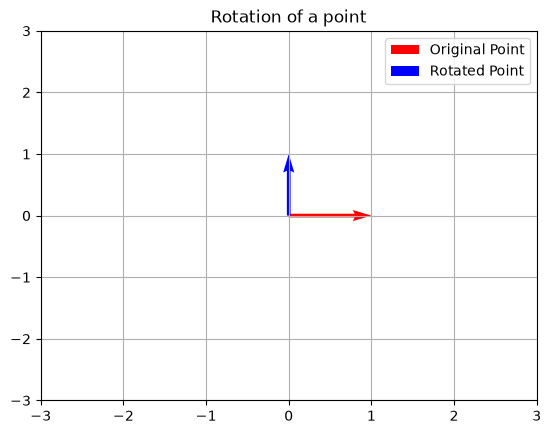

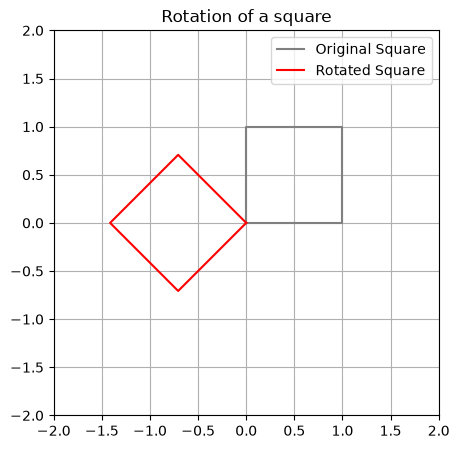

square points: [[0 0]
 [1 0]
 [1 1]
 [0 1]
 [0 0]],  Rotated Rectangle point: [[ 0.00000000e+00  0.00000000e+00]
 [-7.07106781e-01  7.07106781e-01]
 [-1.41421356e+00  1.11022302e-16]
 [-7.07106781e-01 -7.07106781e-01]
 [ 0.00000000e+00  0.00000000e+00]]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

"""
#######         Day 1: vectors and vector addition       #######
v1=np.array([4, 3])
v2=np.array([3, 4])
v3=v1 + v2
plt.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1, color='r', label='v1')
plt.quiver(0, 0, v2[0], v2[1], angles='xy', scale_units='xy', scale=1, color='b', label='v2')
plt.quiver(0, 0, v3[0], v3[1], angles='xy', scale_units='xy', scale=1, color='g', label='v3')
plt.xlim(-10, 10); plt.ylim(-10, 10)
plt.grid(); plt.legend()
plt.title("Two vectors")
plt.show()

def dot_products(a,b):
    total=0
    for i in range(len(a)):
        total+=a[i]*b[i]
    return total

manual_dot=dot_products(v1,v2)
np_dot=np.dot(v1,v2)
print("Manual dot product:", manual_dot)
print("Numpy dot product:", np_dot)
assert manual_dot==np_dot, "Dot products do not match!"



#######         Day2:  Dot products and duality      #######
# Cosine similarity — used constantly in ML (feature similarity, embeddings)
def cosine_similarity(a,b):
    return np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b))


print(f"Cosine similarity: {cosine_similarity(v1, v2):.3f}")

#Same direction vectors
s1=np.array([1, 1])
s2=np.array([2, 2])
print(f"Cosine similarity (same direction): {cosine_similarity(s1, s2):.3f}")   

#Perpendicular vectors
p1=np.array([1, 0])
p2=np.array([0, 1])
print(f"Cosine similarity (perpendicular): {cosine_similarity(p1, p2):.3f}")    

#Opposite direction vectors
o1=np.array([1, 0])
o2=np.array([-1, 0])
print(f"Cosine similarity (opposite direction): {cosine_similarity(o1, o2):.3f}")   


#######         Day 3 — Matrices as Transformations        #######

# A rotation matrix — this is exactly the math behind camera calibration/extrinsics

angle_rad= np.radians(90)
print(f"Angle in rad: {angle_rad:.3f}" )
rotation_matrix=np.array([
                        [np.cos(angle_rad), -np.sin(angle_rad)], 
                        [np.sin(angle_rad), np.cos(angle_rad)]
                        ])

point=np.array([1,0])
rotated_point=rotation_matrix @ point
print(f"Original point: {point},  Rotated point: {rotated_point}")

fig,ax=plt.subplots()
ax.quiver(0, 0, point[0], point[1], angles='xy', scale_units='xy', scale=1, color='r', label='Original Point')
ax.quiver(0, 0, rotated_point[0], rotated_point[1], angles='xy', scale_units='xy', scale=1, color='b', label='Rotated Point')
ax.set_xlim(-3, 3); ax.set_ylim(-3,3)
ax.legend(); ax.grid(); ax.set_title("Rotation of a point")
plt.show()


#Sqaure points
square_points=np.array([[0,0], [1,0], [1,1],[0,1],[0,0]])
def rotate_rectangle(points, theta_deg):
    angle_rad=np.radians(theta_deg)
    rotation_matrix=np.array([
                        [np.cos(angle_rad), -np.sin(angle_rad)],
                        [np.sin(angle_rad), np.cos(angle_rad)]
                        ])
    return points @ rotation_matrix.T



fig,ax=plt.subplots(figsize=(5,5))    
rotated_rectangle=rotate_rectangle(square_points, 135)
ax.plot(square_points[:,0], square_points[:,1], 'gray', label='Original Square')
ax.plot(rotated_rectangle[:,0], rotated_rectangle[:,1], 'red', label='Rotated Square')
ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
ax.legend(); ax.grid(); ax.set_title("Rotation of a square");ax.set_aspect('equal')
plt.show()

print(f"square points: {square_points},  Rotated Rectangle point: {rotated_rectangle}")

"""





In [15]:
#######         Day 4 — Matrix Multiplication From Scratch       #######
def matmul_scratch(A, B):
    rows_A, cols_A = A.shape
    rows_B, cols_B = B.shape
    assert cols_A == rows_B, "Incompatible shapes"
    result = np.zeros((rows_A, cols_B))
    for i in range(rows_A):
        for j in range(cols_B):
            for k in range(cols_A):
                result[i][j] += A[i][k] * B[k][j]
    return result

A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

manual = matmul_scratch(A, B)
numpy_result = A @ B
assert np.allclose(manual, numpy_result)
print("Matches NumPy!")
print(manual)

import time

# Bigger matrices this time
A_big = np.random.rand(100, 100)
B_big = np.random.rand(100, 100)

start = time.time()
manual_result = matmul_scratch(A_big, B_big)
manual_time = time.time() - start

start = time.time()
numpy_result = A_big @ B_big
numpy_time = time.time() - start

print(f"Manual (scratch): {manual_time:.4f} sec")
print(f"NumPy (@):        {numpy_time:.4f} sec")
print(f"NumPy is {manual_time/numpy_time:.0f}x faster")

Matches NumPy!
[[19. 22.]
 [43. 50.]]
Manual (scratch): 0.3756 sec
NumPy (@):        0.0003 sec
NumPy is 1313x faster
